# 问题


用Fisher方法完成两类样本模式识别分类投影图，得出F1和F2的表达式。
两类 Fisher 线性判别的分类函数形式

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1.输入数据

In [2]:
# 每行格式: [类别, U1/V, U2/V, t1/s, t2/s]
data = [
    [1, 2, 150, 3.5, 7, 1],
    [2, 2, 110, 4.1, 6, 1],
    [3, 2, 180, 4.0, 6, 1],
    [4, 2, 110, 3.8, 6, 0.5],
    [5, 2, 200, 3.0, 7, 1],
    [6, 1, 200, 4.5, 6, 0.5],
    [7, 1, 120, 4.5, 6, 0.5],
    [8, 1, 200, 3.0, 7, 0.5],
    [9, 1, 125, 3.5, 7, 0.5],
    [10, 1, 150, 4.0, 7, 0.5],
    [11, 1, 125, 4.0, 6, 0.5],
    [12, 1, 170, 3.8, 7, 1],
    [13, 1, 180, 3.5, 7, 1],
]

columns = ['序号', '样本类别', 'U1', 'U2', 't1', 't2']
df = pd.DataFrame(data, columns=columns)

X = df[['U1', 'U2', 't1', 't2']].values.astype(float)
y = df['样本类别'].values

# 第1类、第2类
X1 = X[y == 1]
X2 = X[y == 2]

n1 = len(X1)
n2 = len(X2)

#  2. 计算两类均值向量

In [3]:
mu1 = np.mean(X1, axis=0).reshape(-1, 1)
mu2 = np.mean(X2, axis=0).reshape(-1, 1)

print("【Step 1】两类均值向量")
print("mu1 =\n", mu1)
print("mu2 =\n", mu2)

【Step 1】两类均值向量
mu1 =
 [[158.75 ]
 [  3.85 ]
 [  6.625]
 [  0.625]]
mu2 =
 [[150.  ]
 [  3.68]
 [  6.4 ]
 [  0.9 ]]


# 3. 两类协方差矩阵

In [4]:
S1 = np.cov(X1, rowvar=False, bias=False)
S2 = np.cov(X2, rowvar=False, bias=False)

print("\n【Step 2】两类协方差矩阵")
print("S1 =\n", S1)
print("S2 =\n", S2)


【Step 2】两类协方差矩阵
S1 =
 [[ 1.11964286e+03 -5.14285714e+00  4.46428571e+00  2.32142857e+00]
 [-5.14285714e+00  2.65714286e-01 -2.07142857e-01 -2.85714286e-02]
 [ 4.46428571e+00 -2.07142857e-01  2.67857143e-01  5.35714286e-02]
 [ 2.32142857e+00 -2.85714286e-02  5.35714286e-02  5.35714286e-02]]
S2 =
 [[ 1.65e+03 -1.15e+01  1.25e+01  5.00e+00]
 [-1.15e+01  1.97e-01 -2.15e-01 -1.50e-02]
 [ 1.25e+01 -2.15e-01  3.00e-01  5.00e-02]
 [ 5.00e+00 -1.50e-02  5.00e-02  5.00e-02]]


# 4. 合并协方差矩阵

In [5]:
Sigma = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)

print("\n【Step 3】合并协方差矩阵 Sigma")
print("Sigma =\n", Sigma)




【Step 3】合并协方差矩阵 Sigma
Sigma =
 [[ 1.31250000e+03 -7.45454545e+00  7.38636364e+00  3.29545455e+00]
 [-7.45454545e+00  2.40727273e-01 -2.10000000e-01 -2.36363636e-02]
 [ 7.38636364e+00 -2.10000000e-01  2.79545455e-01  5.22727273e-02]
 [ 3.29545455e+00 -2.36363636e-02  5.22727273e-02  5.22727273e-02]]


# 5.逆矩阵

In [6]:
Sigma_inv = np.linalg.inv(Sigma)

print("\n【Step 4】Sigma 的逆矩阵")
print("Sigma_inv =\n", Sigma_inv)


【Step 4】Sigma 的逆矩阵
Sigma_inv =
 [[ 1.06055843e-03  3.58441282e-02  1.03021333e-02 -6.09556460e-02]
 [ 3.58441282e-02  1.41612263e+01  1.09670112e+01 -6.82341266e+00]
 [ 1.03021333e-02  1.09670112e+01  1.32075108e+01 -8.89799675e+00]
 [-6.09556460e-02 -6.82341266e+00 -8.89799675e+00  2.87859183e+01]]


# 6. 建立Fisher判别函数


In [7]:
# Fk(x)=x^T Sigma^{-1} muk - 1/2 muk^T Sigma^{-1} muk

a1 = Sigma_inv @ mu1
a2 = Sigma_inv @ mu2

a10 = -0.5 * (mu1.T @ Sigma_inv @ mu1)[0, 0]
a20 = -0.5 * (mu2.T @ Sigma_inv @ mu2)[0, 0]

print("\n【Step 5】Fisher 判别函数系数")
print("Sigma_inv * mu1 =\n", a1)
print("Sigma_inv * mu2 =\n", a2)
print("a10 =", a10)
print("a20 =", a20)

# 判别函数值
F1 = X @ a1.flatten() + a10
F2 = X @ a2.flatten() + a20

# 预测类别
pred = np.where(F1 > F2, 1, 2)

df['F1'] = F1
df['F2'] = F2
df['预测类别'] = pred


【Step 5】Fisher 判别函数系数
Sigma_inv * mu1 =
 [[  0.3365179 ]
 [128.60279309]
 [125.79696816]
 [-76.90487708]]
Sigma_inv * mu2 =
 [[  0.30206373]
 [121.53773249]
 [118.42379354]
 [-65.29335823]]
a10 = -666.9411678507287
a20 = -595.8583355129423


# 7. 展开表达式

In [8]:
print("\n【Step 6】展开得到 F1, F2")
print(f"F1 = {a10:.6f} + ({a1[0,0]:.6f})*U1 + ({a1[1,0]:.6f})*U2 + ({a1[2,0]:.6f})*t1 + ({a1[3,0]:.6f})*t2")
print(f"F2 = {a20:.6f} + ({a2[0,0]:.6f})*U1 + ({a2[1,0]:.6f})*U2 + ({a2[2,0]:.6f})*t1 + ({a2[3,0]:.6f})*t2")

print("\n各样本判别结果：")
print(df[['序号', '样本类别', 'F1', 'F2', '预测类别']])

# 分类准确率
acc = np.mean(df['样本类别'] == df['预测类别'])
print(f"\n分类准确率: {acc:.4f}")


【Step 6】展开得到 F1, F2
F1 = -666.941168 + (0.336518)*U1 + (128.602793)*U2 + (125.796968)*t1 + (-76.904877)*t2
F2 = -595.858336 + (0.302064)*U1 + (121.537732)*U2 + (118.423794)*t1 + (-65.293358)*t2

各样本判别结果：
    序号  样本类别          F1          F2  预测类别
0    1     2  637.320193  638.506484     2
1    2     2  575.224185  580.922781     2
2    3     2  585.920158  589.913469     2
3    4     2  575.095785  577.108140     2
4    5     2  589.844691  592.840804     2
5    6     1  695.404351  689.370288     1
6    7     1  668.482919  665.205190     1
7    8     1  628.297130  625.487483     1
8    9     1  667.359684  663.601570     1
9   10     1  740.074028  731.922029     1
10  11     1  605.864112  605.946643     2
11  12     1  682.631389  681.009078     1
12  13     1  647.415730  647.568396     2

分类准确率: 0.8462


# 8. 画二维投影图


/var/folders/mr/1t74t_w14t325hfk7jdxq8_r0000gn/T/ipykernel_39004/4170790917.py:17: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mr/1t74t_w14t325hfk7jdxq8_r0000gn/T/ipykernel_39004/4170790917.py:17: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mr/1t74t_w14t325hfk7jdxq8_r0000gn/T/ipykernel_39004/4170790917.py:17: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mr/1t74t_w14t325hfk7jdxq8_r0000gn/T/ipykernel_39004/4170790917.py:17: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mr/1t74t_w14t325hfk7jdxq8_r0000gn/T/ipykernel_39004/4170790917.py:17: UserWarning: Glyph 21028 (\N{CJK UNIFIED IDEOGRAPH-5224}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mr/1t74

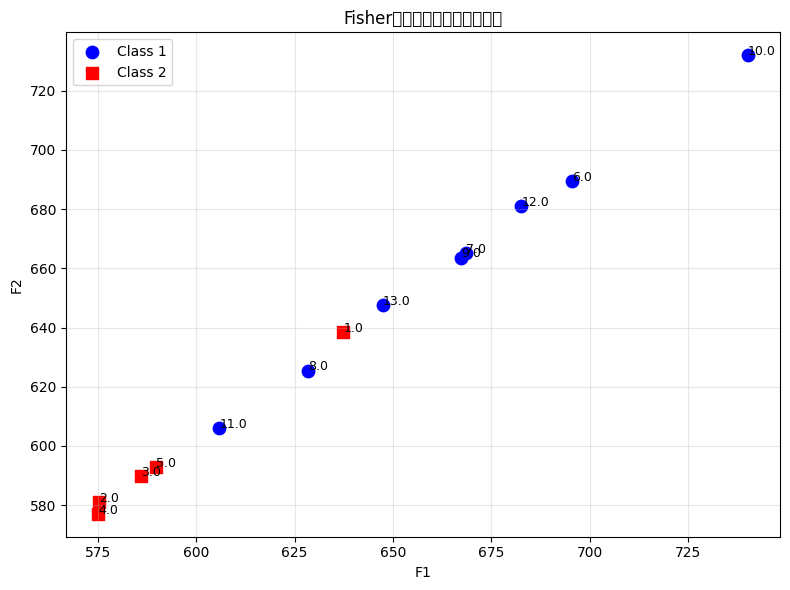

In [9]:
# 横轴 F1，纵轴 F2

plt.figure(figsize=(8, 6))

for cls, color, marker in [(1, 'blue', 'o'), (2, 'red', 's')]:
    idx = (y == cls)
    plt.scatter(F1[idx], F2[idx], c=color, marker=marker, s=80, label=f'Class {cls}')

for i in range(len(df)):
    plt.text(F1[i] + 0.05, F2[i] + 0.05, str(df.iloc[i]['序号']), fontsize=9)

plt.xlabel('F1')
plt.ylabel('F2')
plt.title('Fisher两类样本判别二维投影图')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()